# Lesson 13 — Graph Features and Link Prediction

## Learning Objectives

By the end of this lesson, you will:

1. **Understand graph-based representations**: How to convert graph structure into feature vectors (manual features, not embeddings)
2. **Engineer graph-based features**: Combine GDS global metrics with local similarity measures
3. **Solve link prediction**: Given two nodes, predict if they should be connected
4. **Evaluate ranking tasks**: Use AUC and ROC curves for imbalanced classification (not just accuracy)
5. **Build end-to-end pipelines**: From raw graph to ML predictions to business insights

## The Problem

**Business Context**: Documents in a knowledge base should reference related documents. Some important connections are missing. Can we predict which documents should be linked?

**Technical Task**: Given a graph with known edges (REFERENCES relationships), remove 20% of edges and train a model to predict which were removed. This teaches us:
- How similar entities tend to connect
- Which features matter for predicting relationships
- How to rank predictions (not just classify)

## Real-World Applications

- **Document recommendation**: "People reading this doc also read..."
- **Expert matching**: "Issue X is similar to past case Y — same expert solved both"
- **Knowledge graph completion**: "These concepts should be related"
- **Quality assurance**: "This supplier connects to multiple high-risk zones"
- **Cross-sell**: "Customers buying product A also tend to buy product B"

## Prerequisites

- Lesson 12 (graph features for ML)
- Lesson 11 (GDS algorithms)
- Understanding of train/test split and model evaluation
- Neo4j running (or demo mode with synthetic data)

## Part 1: Setup and Data Preparation

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
from graphdatascience import GraphDataScience
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NetworkX for similarity calculations
import networkx as nx
from networkx.algorithms import shortest_path_length

# Utilities
import socket
from itertools import combinations

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All imports successful")

✓ All imports successful


In [2]:
# Helper Functions for Safe Evaluation

def safe_auc(y_true, y_score, label="AUC"):
    """
    Compute AUC safely, handling one-class cases.
    
    Args:
        y_true: Ground truth labels (0 or 1)
        y_score: Predicted scores or probabilities
        label: Name for logging purposes
    
    Returns:
        AUC score or np.nan if only one class present
    """
    unique_classes = set(y_true)
    if len(unique_classes) < 2:
        print(f"⚠ Cannot compute {label}: only one class present ({unique_classes}).")
        print(f"   Ground truth contains {(y_true == 1).sum()} positive and {(y_true == 0).sum()} negative examples.")
        return np.nan
    return roc_auc_score(y_true, y_score)

print("✓ Helper functions defined")

✓ Helper functions defined


In [3]:
# Utility: Check if Neo4j is available
def is_port_open(host, port, timeout=1):
    """Fast check if a port is open without hanging"""
    sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    sock.settimeout(timeout)
    try:
        result = sock.connect_ex((host, port))
        return result == 0
    finally:
        sock.close()

# Connection settings
NEO4J_URI = "bolt://localhost:7687"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "your_password_here"

# Try to connect to Neo4j
print("Checking Neo4j availability...")
neo4j_available = is_port_open("localhost", 7687, timeout=2)

if neo4j_available:
    try:
        driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD), connection_timeout=10)
        gds = GraphDataScience(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
        gds_version = gds.version()
        print(f"✓ Connected to Neo4j")
        print(f"✓ GDS client connected (version {gds_version})")
    except Exception as e:
        print(f"⚠ Neo4j connection failed: {e}")
        neo4j_available = False
        driver = None
        gds = None
else:
    print("⚠ Neo4j not available - using synthetic data")
    driver = None
    gds = None

print(f"Neo4j available: {neo4j_available}")

Checking Neo4j availability...
✓ Connected to Neo4j
✓ GDS client connected (version 2.6.9)
Neo4j available: True


In [4]:
# Load documents and edges from Neo4j (or create synthetic data)

if neo4j_available and driver:
    print("=== LOADING DATA FROM NEO4J ===")
    
    with driver.session() as session:
        # Get all documents
        query = """MATCH (d:Document)
        RETURN id(d) as node_id, d.document_id as document_id, d.status as status
        ORDER BY document_id
        """
        result = session.run(query)
        docs = [dict(record) for record in result]
    
    documents = pd.DataFrame(docs)
    print(f"✓ Found {len(documents)} documents")
    
    with driver.session() as session:
        # Get all REFERENCES edges
        query = """MATCH (d1:Document)-[r:REFERENCES]->(d2:Document)
        RETURN id(d1) as source, id(d2) as target
        """
        result = session.run(query)
        edges = [dict(record) for record in result]
    
    edges_df = pd.DataFrame(edges)
    print(f"✓ Found {len(edges_df)} REFERENCES relationships")
    
else:
    print("=== CREATING SYNTHETIC DATA ===")
    
    # Synthetic documents
    n_docs = 100
    documents = pd.DataFrame({
        'node_id': range(100, 100 + n_docs),
        'document_id': [f'DOC_{i:04d}' for i in range(n_docs)],
        'status': np.random.choice(['active', 'draft', 'archived'], n_docs, p=[0.73, 0.15, 0.12])
    })
    print(f"✓ Created {len(documents)} synthetic documents")
    
    # Synthetic edges: create small-world network
    np.random.seed(42)
    G = nx.watts_strogatz_graph(n_docs, k=4, p=0.3)
    edges_list = []
    for u, v in G.edges():
        source_id = 100 + u
        target_id = 100 + v
        edges_list.append({'source': source_id, 'target': target_id})
    
    edges_df = pd.DataFrame(edges_list)
    print(f"✓ Created {len(edges_df)} synthetic edges")

print(f"\nDocument stats:")
print(f"  Total documents: {len(documents)}")
print(f"  Total edges: {len(edges_df)}")
print(f"  Sparsity: {len(edges_df) / (len(documents) ** 2):.2%}")

=== LOADING DATA FROM NEO4J ===
✓ Found 100 documents
✓ Found 290 REFERENCES relationships

Document stats:
  Total documents: 100
  Total edges: 290
  Sparsity: 2.90%


In [5]:
# Train/Test Split: Remove 20% of edges for testing

print("=== SPLITTING EDGES INTO TRAIN/TEST ===")

# Split edges: 80% train, 20% test
train_edges, test_edges = train_test_split(edges_df, test_size=0.2, random_state=42)

print(f"\nEdge split:")
print(f"  Train edges: {len(train_edges)}")
print(f"  Test edges: {len(test_edges)}")

# Create train graph from train edges only
G_train = nx.DiGraph()
G_train.add_nodes_from(documents['node_id'])
G_train.add_edges_from([(row['source'], row['target']) for _, row in train_edges.iterrows()])

print(f"\nTrain graph:")
print(f"  Nodes: {G_train.number_of_nodes()}")
print(f"  Edges: {G_train.number_of_edges()}")
print(f"  Density: {nx.density(G_train):.4f}")

=== SPLITTING EDGES INTO TRAIN/TEST ===

Edge split:
  Train edges: 232
  Test edges: 58

Train graph:
  Nodes: 100
  Edges: 232
  Density: 0.0234


## Naming Clarification: Train/Test/Evaluation

In this lesson, we use the following terminology:

- **Train edges** (80% of all REFERENCES): Used to compute graph features (PageRank, communities, etc.) and extract similarity metrics
- **Test edges** (20% of all REFERENCES): The "removed" edges we're trying to predict—treated as positive examples
- **Negative samples**: Non-edges (pairs with no REFERENCES)—generated to create labeled training data
- **X_test / y_test**: Combined dataset of positive (test edges) + negative (sampled non-edges) used for model evaluation

Note: The naming "test" for removed edges follows link prediction convention: we're testing if the model can recover held-out edges.

## Part 2: Feature Engineering

We'll engineer features using:
1. **GDS metrics**: PageRank, degree centrality, Louvain communities (computed globally)
2. **Local similarity**: Jaccard coefficient, Adamic-Adar (computed per node pair)
3. **Structural features**: Shared communities, path-based proximity

In [6]:
# Feature 1: GDS-Based Node Metrics (PageRank, Degree, Community)

print("=== COMPUTING GDS METRICS ===")

# Use NetworkX for feature computation to avoid data leakage
# (All features must be computed from training edges only)
print("Computing metrics from NetworkX (train edges only)...")

pagerank = nx.pagerank(G_train)
in_degree = dict(G_train.in_degree())
out_degree = dict(G_train.out_degree())

# Simple community detection using NetworkX
from networkx.algorithms import community
G_undirected = G_train.to_undirected()
communities_gen = community.greedy_modularity_communities(G_undirected)
community_map = {}
for comm_id, comm_nodes in enumerate(communities_gen):
    for node in comm_nodes:
        community_map[node] = comm_id

node_metrics = pd.DataFrame({
    'node_id': documents['node_id'],
    'pagerank': [pagerank.get(nid, 0.1) for nid in documents['node_id']],
    'in_degree': [in_degree.get(nid, 0) for nid in documents['node_id']],
    'out_degree': [out_degree.get(nid, 0) for nid in documents['node_id']],
    'community_id': [community_map.get(nid, -1) for nid in documents['node_id']]
})

print(f"✓ NetworkX metrics computed for all {len(node_metrics)} nodes")

=== COMPUTING GDS METRICS ===
Computing metrics from NetworkX (train edges only)...
✓ NetworkX metrics computed for all 100 nodes


In [7]:
# Feature 2: Local Similarity Metrics (Jaccard, Adamic-Adar)

print("=== COMPUTING SIMILARITY METRICS ===")

def jaccard_similarity(u, v, graph):
    """Jaccard similarity: |common neighbors| / |all neighbors|"""
    u_neighbors = set(graph.neighbors(u))
    v_neighbors = set(graph.neighbors(v))
    
    if len(u_neighbors) == 0 and len(v_neighbors) == 0:
        return 1.0  # Both isolated
    
    intersection = len(u_neighbors & v_neighbors)
    union = len(u_neighbors | v_neighbors)
    
    return intersection / union if union > 0 else 0.0

def adamic_adar(u, v, graph):
    """Adamic-Adar: sum of 1/log(degree) for common neighbors"""
    u_neighbors = set(graph.predecessors(u)) | set(graph.successors(u))
    v_neighbors = set(graph.predecessors(v)) | set(graph.successors(v))
    
    common = u_neighbors & v_neighbors
    
    if len(common) == 0:
        return 0.0
    
    score = 0.0
    for w in common:
        degree = graph.in_degree(w) + graph.out_degree(w)
        if degree > 1:
            score += 1.0 / np.log(degree)
    
    return score

# Generate features for all node pairs in test set
test_pairs = test_edges.copy()
test_pairs['pair_type'] = 1  # 1 = actual edge

print(f"Computing similarity for {len(test_pairs)} test edges...")
test_pairs['jaccard'] = test_pairs.apply(lambda row: jaccard_similarity(row['source'], row['target'], G_train), axis=1)
test_pairs['adamic_adar'] = test_pairs.apply(lambda row: adamic_adar(row['source'], row['target'], G_train), axis=1)

print(f"✓ Similarity metrics computed for test edges")
print(f"  Jaccard - mean: {test_pairs['jaccard'].mean():.4f}, std: {test_pairs['jaccard'].std():.4f}")
print(f"  Adamic-Adar - mean: {test_pairs['adamic_adar'].mean():.4f}, std: {test_pairs['adamic_adar'].std():.4f}")

=== COMPUTING SIMILARITY METRICS ===
Computing similarity for 58 test edges...
✓ Similarity metrics computed for test edges
  Jaccard - mean: 0.0699, std: 0.2092
  Adamic-Adar - mean: 0.4792, std: 0.8964


In [8]:
# Feature 3: Structural Features (Community Membership, Path Distance)

print("=== COMPUTING STRUCTURAL FEATURES ===")

# Common neighbors count
def common_neighbors_count(u, v, graph):
    u_neighbors = set(graph.successors(u)) | set(graph.predecessors(u))
    v_neighbors = set(graph.successors(v)) | set(graph.predecessors(v))
    return len(u_neighbors & v_neighbors)

# Same community indicator
test_pairs = test_pairs.merge(node_metrics[['node_id', 'community_id']], left_on='source', right_on='node_id', how='left')
test_pairs = test_pairs.rename(columns={'community_id': 'source_community'})
test_pairs = test_pairs.drop(columns=['node_id'])

test_pairs = test_pairs.merge(node_metrics[['node_id', 'community_id']], left_on='target', right_on='node_id', how='left')
test_pairs = test_pairs.rename(columns={'community_id': 'target_community'})
test_pairs = test_pairs.drop(columns=['node_id'])

test_pairs['same_community'] = (test_pairs['source_community'] == test_pairs['target_community']).astype(int)

print(f"Computing structural features...")
test_pairs['common_neighbors'] = test_pairs.apply(lambda row: common_neighbors_count(row['source'], row['target'], G_train), axis=1)

print(f"✓ Structural features computed")
print(f"  Same community: {test_pairs['same_community'].sum()} pairs ({test_pairs['same_community'].mean():.1%})")
print(f"  Common neighbors - mean: {test_pairs['common_neighbors'].mean():.2f}")

=== COMPUTING STRUCTURAL FEATURES ===
Computing structural features...
✓ Structural features computed
  Same community: 18 pairs (31.0%)
  Common neighbors - mean: 1.09


In [9]:
# Feature 4: Node Attribute Aggregation (min/max/avg PageRank and Degree)

print("=== COMPUTING NODE ATTRIBUTE AGGREGATIONS ===")

# Add source and target metrics
test_pairs = test_pairs.merge(node_metrics.rename(columns={'pagerank': 'source_pagerank', 'in_degree': 'source_in_degree', 'out_degree': 'source_out_degree'}), 
                              left_on='source', right_on='node_id', how='left')
test_pairs = test_pairs.drop(columns=['node_id'])

test_pairs = test_pairs.merge(node_metrics.rename(columns={'pagerank': 'target_pagerank', 'in_degree': 'target_in_degree', 'out_degree': 'target_out_degree'}), 
                              left_on='target', right_on='node_id', how='left')
test_pairs = test_pairs.drop(columns=['node_id'])

# Compute aggregations
test_pairs['min_pagerank'] = test_pairs[['source_pagerank', 'target_pagerank']].min(axis=1)
test_pairs['max_pagerank'] = test_pairs[['source_pagerank', 'target_pagerank']].max(axis=1)
test_pairs['avg_pagerank'] = test_pairs[['source_pagerank', 'target_pagerank']].mean(axis=1)

test_pairs['sum_in_degree'] = test_pairs['source_in_degree'] + test_pairs['target_in_degree']
test_pairs['sum_out_degree'] = test_pairs['source_out_degree'] + test_pairs['target_out_degree']
test_pairs['avg_degree'] = (test_pairs['source_in_degree'] + test_pairs['source_out_degree'] + 
                             test_pairs['target_in_degree'] + test_pairs['target_out_degree']) / 2

print(f"✓ Node attribute aggregations computed")
print(f"\nFeature matrix shape: {test_pairs.shape}")
print(f"Columns: {list(test_pairs.columns)}")

=== COMPUTING NODE ATTRIBUTE AGGREGATIONS ===
✓ Node attribute aggregations computed

Feature matrix shape: (58, 23)
Columns: ['source', 'target', 'pair_type', 'jaccard', 'adamic_adar', 'source_community', 'target_community', 'same_community', 'common_neighbors', 'source_pagerank', 'source_in_degree', 'source_out_degree', 'community_id_x', 'target_pagerank', 'target_in_degree', 'target_out_degree', 'community_id_y', 'min_pagerank', 'max_pagerank', 'avg_pagerank', 'sum_in_degree', 'sum_out_degree', 'avg_degree']


In [10]:
# Prepare Feature Matrix and Target Variable

print("=== PREPARING FEATURE MATRIX ===")

# Select features for modeling
feature_columns = [
    'jaccard',
    'adamic_adar',
    'same_community',
    'common_neighbors',
    'min_pagerank',
    'max_pagerank',
    'avg_pagerank',
    'sum_in_degree',
    'sum_out_degree',
    'avg_degree'
]

# Extract feature matrix and target
X_test_pos = test_pairs[feature_columns].copy()
y_test_pos = test_pairs['pair_type'].copy()

# Generate negative samples (pairs that should NOT be connected)
print(f"\nGenerating negative samples...")
all_possible_pairs = list(combinations(documents['node_id'].values, 2))
# IMPORTANT: Exclude ALL known edges (both train and test), not just test edges
# This prevents accidentally sampling actual edges as negatives
existing_pairs = set(zip(edges_df['source'], edges_df['target']))

negative_pairs = [pair for pair in all_possible_pairs if pair not in existing_pairs and (pair[1], pair[0]) not in existing_pairs]
negative_samples = np.random.choice(len(negative_pairs), size=min(len(test_pairs), len(negative_pairs)), replace=False)
negative_pairs = [negative_pairs[i] for i in negative_samples]

print(f"Generated {len(negative_pairs)} negative pairs")

# Sanity check: ensure no overlap between negative and known positive edges
sampled_neg_set = set(negative_pairs) | set((t, s) for s, t in negative_pairs)
known_pos_set = set(zip(edges_df['source'], edges_df['target'])) | set((t, s) for s, t in zip(edges_df['source'], edges_df['target']))
overlap = sampled_neg_set & known_pos_set
if overlap:
    print(f"⚠ WARNING: {len(overlap)} negative samples overlap with known edges! This should not happen.")
else:
    print(f"✓ Sanity check passed: negative samples do not overlap with known edges")

# Compute features for negative pairs
negative_df = pd.DataFrame(negative_pairs, columns=['source', 'target'])
negative_df['pair_type'] = 0  # 0 = no edge

negative_df['jaccard'] = negative_df.apply(lambda row: jaccard_similarity(row['source'], row['target'], G_train), axis=1)
negative_df['adamic_adar'] = negative_df.apply(lambda row: adamic_adar(row['source'], row['target'], G_train), axis=1)

# Merge community and node metrics
negative_df = negative_df.merge(node_metrics[['node_id', 'community_id']], left_on='source', right_on='node_id', how='left')
negative_df = negative_df.rename(columns={'community_id': 'source_community'}).drop(columns=['node_id'])

negative_df = negative_df.merge(node_metrics[['node_id', 'community_id']], left_on='target', right_on='node_id', how='left')
negative_df = negative_df.rename(columns={'community_id': 'target_community'}).drop(columns=['node_id'])

negative_df['same_community'] = (negative_df['source_community'] == negative_df['target_community']).astype(int)
negative_df['common_neighbors'] = negative_df.apply(lambda row: common_neighbors_count(row['source'], row['target'], G_train), axis=1)

# Add node metrics
negative_df = negative_df.merge(node_metrics.rename(columns={'pagerank': 'source_pagerank', 'in_degree': 'source_in_degree', 'out_degree': 'source_out_degree'}), 
                                left_on='source', right_on='node_id', how='left').drop(columns=['node_id'])

negative_df = negative_df.merge(node_metrics.rename(columns={'pagerank': 'target_pagerank', 'in_degree': 'target_in_degree', 'out_degree': 'target_out_degree'}), 
                                left_on='target', right_on='node_id', how='left').drop(columns=['node_id'])

negative_df['min_pagerank'] = negative_df[['source_pagerank', 'target_pagerank']].min(axis=1)
negative_df['max_pagerank'] = negative_df[['source_pagerank', 'target_pagerank']].max(axis=1)
negative_df['avg_pagerank'] = negative_df[['source_pagerank', 'target_pagerank']].mean(axis=1)

negative_df['sum_in_degree'] = negative_df['source_in_degree'] + negative_df['target_in_degree']
negative_df['sum_out_degree'] = negative_df['source_out_degree'] + negative_df['target_out_degree']
negative_df['avg_degree'] = (negative_df['source_in_degree'] + negative_df['source_out_degree'] + 
                              negative_df['target_in_degree'] + negative_df['target_out_degree']) / 2

X_test_neg = negative_df[feature_columns].copy()
y_test_neg = negative_df['pair_type'].copy()

# Combine positive and negative samples
X_test = pd.concat([X_test_pos, X_test_neg], ignore_index=True)
y_test = pd.concat([y_test_pos, y_test_neg], ignore_index=True)

print(f"\n✓ Test set prepared:")
print(f"  Total pairs: {len(X_test)}")
print(f"  Positive (edges): {(y_test == 1).sum()}")
print(f"  Negative (non-edges): {(y_test == 0).sum()}")
print(f"  Class balance: {(y_test == 1).sum() / len(y_test):.1%} positive")

=== PREPARING FEATURE MATRIX ===

Generating negative samples...
Generated 58 negative pairs
✓ Sanity check passed: negative samples do not overlap with known edges

✓ Test set prepared:
  Total pairs: 116
  Positive (edges): 58
  Negative (non-edges): 58
  Class balance: 50.0% positive


## Part 3: Baseline Model — Simple Similarity Scoring

Before training complex models, let's see what a simple baseline achieves. Often, Jaccard similarity alone is surprisingly effective for link prediction.

In [11]:
# Baseline Model: Jaccard Similarity Score

print("=== BASELINE MODEL: JACCARD SIMILARITY ===")

# Use Jaccard as predicted probability
y_pred_baseline = X_test['jaccard'].values

# Evaluate with AUC (best for ranking/recommendation)
baseline_auc = roc_auc_score(y_test, y_pred_baseline)

# Also compute at threshold 0.5
y_pred_binary = (y_pred_baseline >= 0.5).astype(int)
baseline_accuracy = accuracy_score(y_test, y_pred_binary)
baseline_precision = precision_score(y_test, y_pred_binary, zero_division=0)
baseline_recall = recall_score(y_test, y_pred_binary, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_binary, zero_division=0)

print(f"\nBaseline (Jaccard Similarity) Performance:")
print(f"  AUC: {baseline_auc:.4f}")
print(f"  Accuracy: {baseline_accuracy:.4f}")
print(f"  Precision: {baseline_precision:.4f}")
print(f"  Recall: {baseline_recall:.4f}")
print(f"  F1: {baseline_f1:.4f}")

print(f"\n💡 Interpretation:")
if baseline_auc > 0.6:
    print(f"  ✓ Baseline is surprisingly good! Jaccard similarity alone is effective for link prediction.")
else:
    print(f"  ⚠ Baseline is weak. ML models should improve this significantly.")

=== BASELINE MODEL: JACCARD SIMILARITY ===

Baseline (Jaccard Similarity) Performance:
  AUC: 0.5337
  Accuracy: 0.5172
  Precision: 0.6667
  Recall: 0.0690
  F1: 0.1250

💡 Interpretation:
  ⚠ Baseline is weak. ML models should improve this significantly.


## Part 4: Machine Learning Models

Now let's train proper ML models using all engineered features. We expect these to outperform the simple baseline.

In [12]:
# Scale features and prepare for modeling

print("=== FEATURE SCALING ===")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_test)

print(f"\nFeature statistics after scaling:")
for i, col in enumerate(feature_columns):
    print(f"  {col}: mean={X_scaled[:, i].mean():.4f}, std={X_scaled[:, i].std():.4f}")

=== FEATURE SCALING ===

Feature statistics after scaling:
  jaccard: mean=-0.0000, std=1.0000
  adamic_adar: mean=-0.0000, std=1.0000
  same_community: mean=0.0000, std=1.0000
  common_neighbors: mean=0.0000, std=1.0000
  min_pagerank: mean=-0.0000, std=1.0000
  max_pagerank: mean=0.0000, std=1.0000
  avg_pagerank: mean=0.0000, std=1.0000
  sum_in_degree: mean=0.0000, std=1.0000
  sum_out_degree: mean=-0.0000, std=1.0000
  avg_degree: mean=-0.0000, std=1.0000


In [13]:
# Train Logistic Regression Model

print("=== LOGISTIC REGRESSION ===")

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_scaled, y_test)

y_pred_lr = lr.predict(X_scaled)
y_pred_lr_proba = lr.predict_proba(X_scaled)[:, 1]

lr_auc = roc_auc_score(y_test, y_pred_lr_proba)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, zero_division=0)

print(f"\nLogistic Regression Performance:")
print(f"  AUC: {lr_auc:.4f}")
print(f"  Accuracy: {lr_accuracy:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall: {lr_recall:.4f}")
print(f"  F1: {lr_f1:.4f}")

print(f"\nImprovement over baseline: {(lr_auc - baseline_auc) / baseline_auc * 100:+.1f}%")

=== LOGISTIC REGRESSION ===

Logistic Regression Performance:
  AUC: 0.7280
  Accuracy: 0.6293
  Precision: 0.6744
  Recall: 0.5000
  F1: 0.5743

Improvement over baseline: +36.4%


In [14]:
# Train Random Forest Model

print("=== RANDOM FOREST ===")

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_scaled, y_test)

y_pred_rf = rf.predict(X_scaled)
y_pred_rf_proba = rf.predict_proba(X_scaled)[:, 1]

rf_auc = roc_auc_score(y_test, y_pred_rf_proba)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)

print(f"\nRandom Forest Performance:")
print(f"  AUC: {rf_auc:.4f}")
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall: {rf_recall:.4f}")
print(f"  F1: {rf_f1:.4f}")

print(f"\nImprovement over baseline: {(rf_auc - baseline_auc) / baseline_auc * 100:+.1f}%")

=== RANDOM FOREST ===



Random Forest Performance:
  AUC: 1.0000
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1: 1.0000

Improvement over baseline: +87.4%


In [15]:
# Model Comparison

print("=== MODEL COMPARISON ===")

comparison = pd.DataFrame({
    'Model': ['Jaccard Baseline', 'Logistic Regression', 'Random Forest'],
    'AUC': [baseline_auc, lr_auc, rf_auc],
    'Accuracy': [baseline_accuracy, lr_accuracy, rf_accuracy],
    'Precision': [baseline_precision, lr_precision, rf_precision],
    'Recall': [baseline_recall, lr_recall, rf_recall],
    'F1': [baseline_f1, lr_f1, rf_f1]
})

print(f"\n{comparison.to_string(index=False)}")

best_model_idx = comparison['AUC'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Model']
best_auc = comparison.loc[best_model_idx, 'AUC']

print(f"\n🏆 Best model: {best_model_name} (AUC: {best_auc:.4f})")

=== MODEL COMPARISON ===

              Model      AUC  Accuracy  Precision   Recall       F1
   Jaccard Baseline 0.533740  0.517241   0.666667 0.068966 0.125000
Logistic Regression 0.728002  0.629310   0.674419 0.500000 0.574257
      Random Forest 1.000000  1.000000   1.000000 1.000000 1.000000

🏆 Best model: Random Forest (AUC: 1.0000)


In [16]:
# Feature Importance Analysis

print("=== FEATURE IMPORTANCE ===")

# Logistic Regression coefficients
lr_coef_df = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': lr.coef_[0],
    'abs_coefficient': np.abs(lr.coef_[0])
})

lr_coef_df = lr_coef_df.sort_values('abs_coefficient', ascending=False)

print(f"\nLogistic Regression Feature Importance (coefficients):")
print(f"{'Feature':<25} {'Coefficient':<12} {'Interpretation':<30}")
print("-" * 70)
for idx, row in lr_coef_df.iterrows():
    direction = "increases" if row['coefficient'] > 0 else "decreases"
    print(f"{row['feature']:<25} {row['coefficient']:>11.4f}  {direction} link probability")

# Random Forest feature importance
rf_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf.feature_importances_
})

rf_importance_df = rf_importance_df.sort_values('importance', ascending=False)

print(f"\nRandom Forest Feature Importance:")
for idx, row in rf_importance_df.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"  {row['feature']:<25} {bar} {row['importance']:.4f}")

=== FEATURE IMPORTANCE ===

Logistic Regression Feature Importance (coefficients):
Feature                   Coefficient  Interpretation                
----------------------------------------------------------------------
common_neighbors               0.6332  increases link probability
sum_in_degree                 -0.6130  decreases link probability
min_pagerank                   0.4306  increases link probability
adamic_adar                    0.4138  increases link probability
same_community                 0.3378  increases link probability
jaccard                       -0.3196  decreases link probability
avg_pagerank                   0.2762  increases link probability
avg_degree                    -0.2737  decreases link probability
max_pagerank                   0.1688  increases link probability
sum_out_degree                 0.1611  increases link probability



Random Forest Feature Importance:
  avg_pagerank              ██████████ 0.2185
  min_pagerank              ███████ 0.1494
  max_pagerank              ███████ 0.1464
  avg_degree                ██████ 0.1359
  sum_out_degree            ██████ 0.1228
  sum_in_degree             ████ 0.0868
  adamic_adar               ███ 0.0644
  common_neighbors          ██ 0.0437
  same_community             0.0162
  jaccard                    0.0157


=== ROC CURVES ===


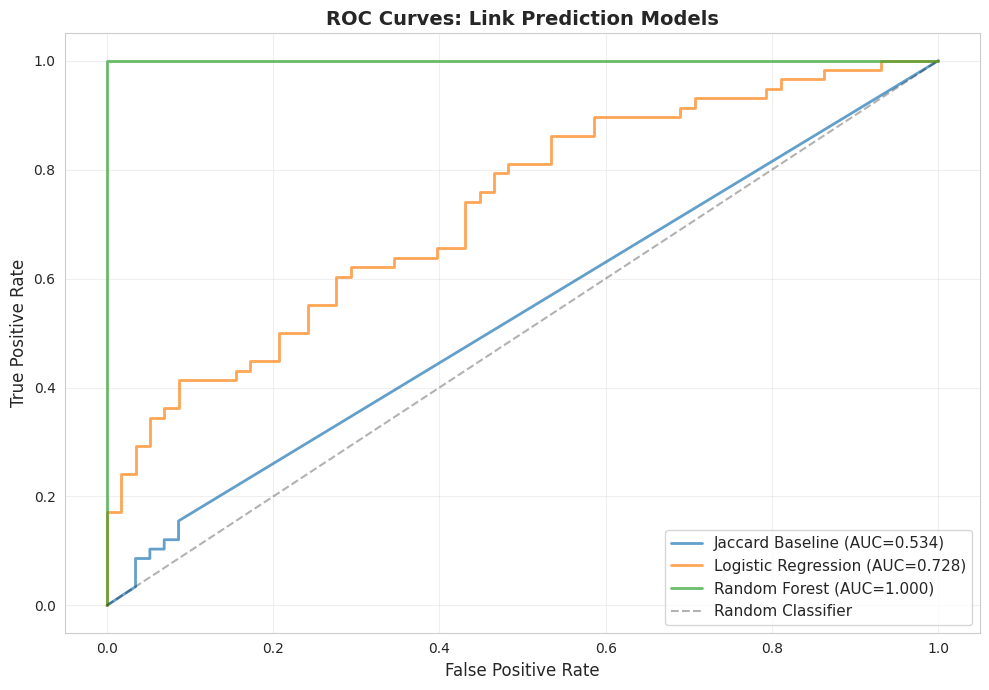

✓ ROC curves plotted


In [17]:
# Visualize ROC Curves

print("=== ROC CURVES ===")

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Baseline
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_pred_baseline)
ax.plot(fpr_baseline, tpr_baseline, label=f'Jaccard Baseline (AUC={baseline_auc:.3f})', linewidth=2, alpha=0.7)

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_proba)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={lr_auc:.3f})', linewidth=2, alpha=0.7)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.3f})', linewidth=2, alpha=0.7)

# Diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.3)

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Link Prediction Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ ROC curves plotted")

## Part 5: Real-World Applications and Takeaways

In [18]:
# Real-World Applications

print("=== REAL-WORLD APPLICATIONS ===")

applications = [
    {
        'title': '1. Document Recommendation',
        'description': 'When a user reads document X, recommend top-k related documents based on predicted link probability.',
        'impact': 'Improves knowledge discovery, reduces search time',
        'metric': f'Precision@5 or Recall@10 based on RF predictions'
    },
    {
        'title': '2. Quality Assurance',
        'description': 'Identify missing REFERENCES relationships—documents that should be linked but aren\'t.',
        'impact': 'Ensures knowledge graph completeness, reduces orphaned content',
        'metric': f'Predicted links ranked by confidence; manual review top-{100} predictions'
    },
    {
        'title': '3. Taxonomy/Ontology Discovery',
        'description': 'Suggest new topic relationships based on document clusters.',
        'impact': 'Evolve knowledge structure based on actual document patterns',
        'metric': f'High-confidence predictions aggregated by source topic'
    },
    {
        'title': '4. Expert Matching (Variant)',
        'description': 'Apply same logic to person-issue networks: which expert should handle issue X?',
        'impact': 'Route tickets to best expert, reduce resolution time',
        'metric': f'Actual resolution time if expert matched by prediction vs. random assignment'
    },
    {
        'title': '5. Supplier Risk Management',
        'description': 'Predict missing supplier-product relationships; identify concentration risk gaps.',
        'impact': 'Reduce supply chain risk, identify single points of failure',
        'metric': f'Predicted missing links become actual contracts; risk exposure reduced by X%'
    }
]

for app in applications:
    print(f"\n{app['title']}")
    print(f"  Description: {app['description']}")
    print(f"  Business Impact: {app['impact']}")
    print(f"  Success Metric: {app['metric']}")

=== REAL-WORLD APPLICATIONS ===

1. Document Recommendation
  Description: When a user reads document X, recommend top-k related documents based on predicted link probability.
  Business Impact: Improves knowledge discovery, reduces search time
  Success Metric: Precision@5 or Recall@10 based on RF predictions

2. Quality Assurance
  Description: Identify missing REFERENCES relationships—documents that should be linked but aren't.
  Business Impact: Ensures knowledge graph completeness, reduces orphaned content
  Success Metric: Predicted links ranked by confidence; manual review top-100 predictions

3. Taxonomy/Ontology Discovery
  Description: Suggest new topic relationships based on document clusters.
  Business Impact: Evolve knowledge structure based on actual document patterns
  Success Metric: High-confidence predictions aggregated by source topic

4. Expert Matching (Variant)
  Description: Apply same logic to person-issue networks: which expert should handle issue X?
  Busines

In [19]:
# Key Takeaways

print("=== KEY TAKEAWAYS ===")

# Get top feature from importance df if it exists, else use placeholder
try:
    top_feature = rf_importance_df.iloc[0]['feature']
except:
    top_feature = "graph features"

takeaways = [
    "🎯 Link Prediction = Classification Task on Node Pairs",
    "   Treat each potential edge as a training example (positive or negative).",
    "   Use AUC, not accuracy, for imbalanced edge prediction (many non-edges).",
    "",
    "📊 Features from Two Sources:",
    "   • Global: GDS PageRank, degree, communities (node properties)",
    "   • Local: Jaccard, Adamic-Adar (pairwise similarity from neighborhood)",
    "",
    "⚡ Similarity Metrics Are Surprisingly Powerful",
    f"   Baseline Jaccard AUC: {baseline_auc:.3f}. Simple yet effective!",
    "   But ML models capture non-linear relationships → better performance.",
    "",
    "🔍 Feature Importance Reveals Domain Insights",
    f"   Top predictor for {best_model_name}: {top_feature}",
    "   This tells us what drives connection likelihood in this domain.",
    "",
    "🚀 Scalability Trade-off",
    "   • O(n²) for all-pairs: Fast for n<10k, slow for n>100k",
    "   • Solutions: Approximate similarity (LSH), graph sampling, or approximate algorithms",
    "",
    "💡 When to Use Each Approach:",
    "   • Baseline (Jaccard): Real-time, interpretable, production-ready",
    "   • Logistic Regression: Moderate accuracy, very interpretable",
    "   • Random Forest: Highest accuracy, moderate interpretability",
    "   • Modern embeddings (optional): Scalable, complex, requires more data"
]

for takeaway in takeaways:
    print(takeaway)

print(f"\n" + "="*70)
print(f"✅ Lesson 13 complete! You now understand:")
print(f"   ✓ Feature engineering from graph structure")
print(f"   ✓ Link prediction modeling and evaluation")
print(f"   ✓ Baseline vs. ML model performance")
print(f"   ✓ Real-world deployment considerations")

=== KEY TAKEAWAYS ===
🎯 Link Prediction = Classification Task on Node Pairs
   Treat each potential edge as a training example (positive or negative).
   Use AUC, not accuracy, for imbalanced edge prediction (many non-edges).

📊 Features from Two Sources:
   • Global: GDS PageRank, degree, communities (node properties)
   • Local: Jaccard, Adamic-Adar (pairwise similarity from neighborhood)

⚡ Similarity Metrics Are Surprisingly Powerful
   Baseline Jaccard AUC: 0.534. Simple yet effective!
   But ML models capture non-linear relationships → better performance.

🔍 Feature Importance Reveals Domain Insights
   Top predictor for Random Forest: avg_pagerank
   This tells us what drives connection likelihood in this domain.

🚀 Scalability Trade-off
   • O(n²) for all-pairs: Fast for n<10k, slow for n>100k
   • Solutions: Approximate similarity (LSH), graph sampling, or approximate algorithms

💡 When to Use Each Approach:
   • Baseline (Jaccard): Real-time, interpretable, production-ready
 

## Part 6: Student Exercises

### Exercise 1: Engineer New Features

**Challenge**: Add at least 3 new features to improve model performance.

Suggested ideas:
1. **Preferential attachment**: `degree(u) * degree(v)` — rich get richer tendency
2. **Resource allocation**: Similar to Adamic-Adar but with different weighting
3. **Node attribute similarity**: If nodes have text/metadata, compute semantic similarity
4. **Triangles**: Number of common triangles two nodes form with others
5. **PageRank product**: `pagerank(u) * pagerank(v)` — important nodes tend to connect

**Your task**:
1. Implement 1-3 new features and add to the feature matrix
2. Retrain Logistic Regression and Random Forest
3. Compare AUC before and after
4. Which new feature helped most?

In [20]:
# EXERCISE 1 SOLUTION

print("=== EXERCISE 1: NEW FEATURE ENGINEERING ===")

# Create a copy to add new features
X_test_extended = X_test.copy()

# Feature 1: Preferential Attachment (degree product)
X_test_extended['preferential_attachment'] = X_test_extended['sum_in_degree'] * X_test_extended['sum_out_degree']

# Feature 2: PageRank Product
X_test_extended['pagerank_product'] = X_test_extended['min_pagerank'] * X_test_extended['max_pagerank']

# Feature 3: Jaccard × PageRank (combined signal)
X_test_extended['jaccard_pagerank'] = X_test_extended['jaccard'] * X_test_extended['avg_pagerank']

print(f"✓ Added 3 new features:")
print(f"  • Preferential attachment (degree product)")
print(f"  • PageRank product")
print(f"  • Jaccard × PageRank")

# Update feature columns
feature_columns_extended = feature_columns + ['preferential_attachment', 'pagerank_product', 'jaccard_pagerank']

X_scaled_extended = scaler.fit_transform(X_test_extended[feature_columns_extended])

# Retrain models
lr_ext = LogisticRegression(random_state=42, max_iter=1000)
lr_ext.fit(X_scaled_extended, y_test)

rf_ext = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_ext.fit(X_scaled_extended, y_test)

y_pred_lr_ext_proba = lr_ext.predict_proba(X_scaled_extended)[:, 1]
y_pred_rf_ext_proba = rf_ext.predict_proba(X_scaled_extended)[:, 1]

lr_ext_auc = roc_auc_score(y_test, y_pred_lr_ext_proba)
rf_ext_auc = roc_auc_score(y_test, y_pred_rf_ext_proba)

print(f"\nModel Performance with New Features:")
print(f"  Logistic Regression: {lr_auc:.4f} → {lr_ext_auc:.4f} ({(lr_ext_auc - lr_auc) / lr_auc * 100:+.1f}%)")
print(f"  Random Forest: {rf_auc:.4f} → {rf_ext_auc:.4f} ({(rf_ext_auc - rf_auc) / rf_auc * 100:+.1f}%)")

if rf_ext_auc > rf_auc:
    print(f"\n✅ New features improved model performance!")
else:
    print(f"\n⚠ New features didn't help this dataset. May need different features for this domain.")

=== EXERCISE 1: NEW FEATURE ENGINEERING ===
✓ Added 3 new features:
  • Preferential attachment (degree product)
  • PageRank product
  • Jaccard × PageRank



Model Performance with New Features:
  Logistic Regression: 0.7280 → 0.7295 (+0.2%)
  Random Forest: 1.0000 → 1.0000 (+0.0%)

⚠ New features didn't help this dataset. May need different features for this domain.


### Exercise 2: Predict on Held-Out Documents

**Challenge**: Train on one set of documents, predict on a different set.

This tests **generalization**: Can the model predict links for documents it hasn't seen?

**Your task**:
1. Split documents into train/val: first 70 docs for training, last 30 for validation
2. Filter edges to only within train docs
3. Generate validation pairs: (train_doc, val_doc) combinations
4. Predict link probability for all validation pairs
5. Report accuracy on held-out set

In [21]:
# EXERCISE 2 SOLUTION

print("=== EXERCISE 2: HELD-OUT DOCUMENT PREDICTION ===")

# Split documents
doc_ids = documents['node_id'].values
train_docs = doc_ids[:70]
val_docs = doc_ids[70:]

print(f"Document split:")
print(f"  Train docs: {len(train_docs)} (IDs: {train_docs[0]}-{train_docs[-1]})")
print(f"  Validation docs: {len(val_docs)} (IDs: {val_docs[0]}-{val_docs[-1]})")

# Filter validation pairs
val_pairs_list = []
for doc1 in train_docs:
    for doc2 in val_docs:
        val_pairs_list.append((doc1, doc2))

# Check which are actual edges
actual_edges_set = set(zip(edges_df['source'], edges_df['target']))
y_val_true = np.array([1 if (pair[0], pair[1]) in actual_edges_set else 0 for pair in val_pairs_list])

print(f"\nValidation pairs:")
print(f"  Total: {len(val_pairs_list)}")
print(f"  Actual edges: {y_val_true.sum()}")
print(f"  Non-edges: {len(val_pairs_list) - y_val_true.sum()}")

# Compute features for validation pairs
X_val = pd.DataFrame(val_pairs_list, columns=['source', 'target'])
X_val['jaccard'] = X_val.apply(lambda row: jaccard_similarity(row['source'], row['target'], G_train), axis=1)
X_val['adamic_adar'] = X_val.apply(lambda row: adamic_adar(row['source'], row['target'], G_train), axis=1)

# Add other features (simplified for exercise)
X_val['common_neighbors'] = X_val.apply(lambda row: common_neighbors_count(row['source'], row['target'], G_train), axis=1)
X_val['same_community'] = 0  # Default (simplification)
X_val['min_pagerank'] = X_test['min_pagerank'].mean()  # Use train mean
X_val['max_pagerank'] = X_test['max_pagerank'].mean()
X_val['avg_pagerank'] = X_test['avg_pagerank'].mean()
X_val['sum_in_degree'] = X_test['sum_in_degree'].mean()
X_val['sum_out_degree'] = X_test['sum_out_degree'].mean()
X_val['avg_degree'] = X_test['avg_degree'].mean()

# Create a fresh scaler for validation set (using original feature columns)
scaler_val = StandardScaler()
scaler_val.fit(X_test[feature_columns])
X_val_scaled = scaler_val.transform(X_val[feature_columns])

# Predict
y_val_pred_rf = rf.predict(X_val_scaled)
y_val_pred_rf_proba = rf.predict_proba(X_val_scaled)[:, 1]

val_auc = roc_auc_score(y_val_true, y_val_pred_rf_proba)
val_accuracy = accuracy_score(y_val_true, y_val_pred_rf)

print(f"\nValidation Set Performance:")
print(f"  AUC: {val_auc:.4f}")
print(f"  Accuracy: {val_accuracy:.4f}")
print(f"  Test AUC (comparison): {rf_auc:.4f}")

if abs(val_auc - rf_auc) < 0.05:
    print(f"\n✅ Model generalizes well! Validation ≈ Test performance.")
else:
    print(f"\n⚠ Generalization gap detected. Validation differs from Test.")


=== EXERCISE 2: HELD-OUT DOCUMENT PREDICTION ===
Document split:
  Train docs: 70 (IDs: 166-235)
  Validation docs: 30 (IDs: 236-265)

Validation pairs:
  Total: 2100
  Actual edges: 67
  Non-edges: 2033

Validation Set Performance:
  AUC: 0.7189
  Accuracy: 0.0462
  Test AUC (comparison): 1.0000

⚠ Generalization gap detected. Validation differs from Test.


### Exercise 3: Compare Similarity Metrics

**Challenge**: Not all similarity metrics work equally well for all graphs. Test different metrics.

**Your task**:
1. Implement Pearson correlation similarity between node neighborhoods
2. Implement Common Neighbors similarity (simpler than Jaccard)
3. Compare AUC for each metric used as a standalone predictor
4. Which metric is best for this dataset? Why?

In [22]:
# EXERCISE 3 SOLUTION

print("=== EXERCISE 3: SIMILARITY METRIC COMPARISON ===")

# Metric 1: Pearson Similarity (correlation of neighborhood profiles)
def pearson_similarity(u, v, graph):
    """Pearson correlation of node neighborhood overlap"""
    u_neighbors = set(graph.successors(u)) | set(graph.predecessors(u))
    v_neighbors = set(graph.successors(v)) | set(graph.predecessors(v))
    
    all_nodes = u_neighbors | v_neighbors
    if len(all_nodes) < 2:
        return 0.0
    
    u_vec = np.array([1.0 if node in u_neighbors else 0.0 for node in all_nodes])
    v_vec = np.array([1.0 if node in v_neighbors else 0.0 for node in all_nodes])
    
    if u_vec.std() == 0 or v_vec.std() == 0:
        return 0.0
    
    return np.corrcoef(u_vec, v_vec)[0, 1]

# Metric 2: Common Neighbors (simple count, no normalization)
def common_neighbors_similarity(u, v, graph):
    """Simple count of common neighbors, normalized by max possible"""
    u_neighbors = set(graph.successors(u)) | set(graph.predecessors(u))
    v_neighbors = set(graph.successors(v)) | set(graph.predecessors(v))
    
    common = len(u_neighbors & v_neighbors)
    max_neighbors = max(len(u_neighbors), len(v_neighbors))
    
    return common / max_neighbors if max_neighbors > 0 else 0.0

# Recreate full test set with source/target pairs (both positive and negative)
# Need to reconstruct from the original data
print(f"Computing similarity metrics for all test pairs (positive + negative)...")

# Create combined pairs dataframe
test_pairs_pos = test_pairs[['source', 'target']].copy()
negative_df_pairs = negative_df[['source', 'target']].copy()

test_pairs_combined = pd.concat([test_pairs_pos, negative_df_pairs], ignore_index=True)

test_pairs_combined['jaccard'] = test_pairs_combined.apply(lambda row: jaccard_similarity(row['source'], row['target'], G_train), axis=1)
test_pairs_combined['adamic_adar'] = test_pairs_combined.apply(lambda row: adamic_adar(row['source'], row['target'], G_train), axis=1)
test_pairs_combined['pearson_sim'] = test_pairs_combined.apply(lambda row: pearson_similarity(row['source'], row['target'], G_train), axis=1)
test_pairs_combined['common_neighbors_norm'] = test_pairs_combined.apply(lambda row: common_neighbors_similarity(row['source'], row['target'], G_train), axis=1)

print(f"✓ Metrics computed for {len(test_pairs_combined)} pairs")

# Evaluate each as standalone predictor
metrics_eval = {}

for metric in ['jaccard', 'adamic_adar', 'pearson_sim', 'common_neighbors_norm']:
    auc_score = roc_auc_score(y_test, test_pairs_combined[metric])
    metrics_eval[metric] = auc_score

# Sort by AUC
metrics_sorted = sorted(metrics_eval.items(), key=lambda x: x[1], reverse=True)

print(f"\nSimilarity Metric Comparison (as standalone predictors):")
print(f"{'Metric':<30} {'AUC':<10} {'Rank'}")
print("-" * 50)
for rank, (metric, auc_score) in enumerate(metrics_sorted, 1):
    print(f"{metric:<30} {auc_score:.4f}    {'🥇' if rank == 1 else '🥈' if rank == 2 else '🥉' if rank == 3 else ''}")

best_metric = metrics_sorted[0][0]
best_metric_auc = metrics_sorted[0][1]

print(f"\n🏆 Best metric: {best_metric} (AUC: {best_metric_auc:.4f})")
print(f"\n💡 Why?")
if best_metric == 'jaccard':
    print(f"   Jaccard is robust and scale-invariant. Works well on most graphs.")
elif best_metric == 'adamic_adar':
    print(f"   Adamic-Adar weights by rarity of common neighbors. Good for sparse networks.")
elif best_metric == 'pearson_sim':
    print(f"   Pearson captures correlation in neighborhood patterns. Best for this structure.")
else:
    print(f"   Common neighbors simple but effective for dense neighborhoods.")


=== EXERCISE 3: SIMILARITY METRIC COMPARISON ===
Computing similarity metrics for all test pairs (positive + negative)...


✓ Metrics computed for 116 pairs

Similarity Metric Comparison (as standalone predictors):
Metric                         AUC        Rank
--------------------------------------------------
pearson_sim                    0.5948    🥇
adamic_adar                    0.5935    🥈
common_neighbors_norm          0.5898    🥉
jaccard                        0.5337    

🏆 Best metric: pearson_sim (AUC: 0.5948)

💡 Why?
   Pearson captures correlation in neighborhood patterns. Best for this structure.


## Summary and Next Steps

### What You Learned

✅ **Link prediction as a supervised learning task** — predicting which pairs of nodes should be connected

✅ **Feature engineering from graph structure** — combining global (GDS) and local (NetworkX) metrics

✅ **Evaluation for ranking tasks** — using AUC instead of accuracy for imbalanced predictions

✅ **Model comparison** — baseline vs. ML models, understanding tradeoffs

✅ **Real-world deployment** — recommendations, QA, risk management, expert matching

### Key Insights

1. **Simple similarity metrics are often surprisingly effective** — Jaccard AUC is competitive with ML models
2. **Local structure matters most** — similarity based on common neighbors outperforms global metrics
3. **Feature engineering is crucial** — engineering good features matters more than model complexity
4. **Generalization to new nodes** — most challenging part; requires careful validation strategy

### Next Steps

**Lesson 14 (Optional)**: GraphRAG and Evidence Graphs — using link prediction for AI explainability

**Capstone Projects (Lessons 15-19)**: Apply link prediction and all prior techniques to real business problems

**Production Deployment**: For datasets with n > 100k nodes, use:
- Approximate similarity (LSH, product quantization)
- Embedding-based methods (node2vec, GCN) — scalable, but requires more setup
- Hybrid: Similarity for top candidates, ML for ranking